# WADI Transfer Entropy, Mutual Information & Partial Correlation Analysis

Applies the same baseline-vs-attack temporal metric methodology used in the CCF/Granger notebook
to three new dependency metrics:

| Metric | Estimator | Captures |
|---|---|---|
| Transfer Entropy (TE) | KNN (npeet) or histogram (pyinform) | Directed information flow |
| Mutual Information (MI) | KNN continuous (npeet) | Symmetric statistical dependence |
| Partial Correlation | OLS via pingouin | Linear correlation, confounder-controlled |

**Methodology**: compute each metric on normal-day baseline data → compute on attack-period data
→ assess whether the deviation is statistically significant at the sensor-pair level.


---
## Configuration
Adjust these parameters before running.

In [3]:
# ── Significance ─────────────────────────────────────────────────────────────
SIGNIFICANCE_ALPHA    = 0.05       # threshold for all significance tests

# ── Transfer Entropy ──────────────────────────────────────────────────────────
# Set to "knn" (continuous, no discretization) or "histogram" (discrete, faster)
TE_ESTIMATOR          = "knn"

TE_HIST_BINS          = 10         # number of histogram bins  [histogram only]
TE_WINSORIZE_PCT      = 1.0        # winsorization percentile  [histogram only]
TE_KNN_K              = 5          # KNN neighbours for TE and MI KDE estimators
TE_HISTORY_LAG        = 1          # conditioning history (k in pyinform; history_target/history_source in idtxl)

# ── Subsampling (TE and MI are O(n log n) — subsample for tractability) ───────
TE_SUBSAMPLE_N        = 8_000      # rows per pair (None = use all available)
MI_SUBSAMPLE_N        = 8_000      # can differ from TE

# ── Deviation significance (z-score threshold for individual-pair flagging) ───
DEVIATION_ZSCORE_THRESH = 2.0      # |z| above this → pair flagged as significant

# ── Partial Correlation ───────────────────────────────────────────────────────
PCORR_NORMALITY_TEST  = "dagostino"  # "shapiro" (n<5000) or "dagostino" (any n)
VIF_THRESHOLD         = 10.0       # flag if any sensor VIF exceeds this


---
## Setup & Imports

In [4]:
import subprocess
subprocess.run(
    ["pip", "install", "-q",
     "pandas", "numpy", "scipy", "statsmodels",
     "polars", "matplotlib", "seaborn", "tqdm", "joblib",
     "idtxl", "pyinform", "pingouin", "upsetplot"],
    check=False
)


ERROR: Could not find a version that satisfies the requirement idtxl (from versions: none)
ERROR: No matching distribution found for idtxl
You should consider upgrading via the '/users/PAS1266/ralston168/WaDi/bin/python3 -m pip install --upgrade pip' command.


CompletedProcess(args=['pip', 'install', '-q', 'pandas', 'numpy', 'scipy', 'statsmodels', 'polars', 'matplotlib', 'seaborn', 'tqdm', 'joblib', 'idtxl', 'pyinform', 'pingouin', 'upsetplot'], returncode=1)

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pickle
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import detrend
from scipy.stats import ks_2samp, zscore
from scipy.stats import normaltest as dagostino_test
from scipy.stats import shapiro
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm
from joblib import Parallel, delayed

import pingouin as pg

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (12, 5)})


In [6]:
# ── File paths ────────────────────────────────────────────────────────────────
DATA_DIR   = Path("../../data/preprocess")
NORMAL_CSV = DATA_DIR / "WADI_normal.csv"
ATTACK_CSV = DATA_DIR / "WADI_attack.csv"
DICT_PATH  = Path("data_dict.csv")
EDGES_CSV  = Path("wadi_edges.csv")          # written by CCF/Granger notebook

TIMESTAMP_FMT = "%Y-%m-%dT%H:%M:%S%.f"

META_COLS = {"sys_unk", "Date", "Time", "timestamp", "attack_label",
             "plant_run_status", "required_flow", "Row", "row"}


---
## Section 1 — Data Loading

In [7]:
# ── Data dictionary ───────────────────────────────────────────────────────────
data_dict = pl.read_csv(DICT_PATH)
print(f"Data dictionary: {data_dict.shape[0]} entries  |  columns: {data_dict.columns}")

sensor_cols_from_dict = (
    data_dict
    .filter(pl.col("kind") == "continuous")
    .filter(pl.col("short_name").is_not_null())
    ["short_name"]
    .to_list()
)
print(f"Continuous sensors in data dict: {len(sensor_cols_from_dict)}")

# ── Load CSVs ─────────────────────────────────────────────────────────────────
print("\nLoading normal days …")
df_normal = pl.read_csv(NORMAL_CSV, infer_schema_length=10_000)
print(f"  shape : {df_normal.shape}")

print("Loading attack days …")
df_attack = pl.read_csv(ATTACK_CSV, infer_schema_length=10_000)
print(f"  shape : {df_attack.shape}")


Data dictionary: 124 entries  |  columns: ['column', 'zone', 'stage', 'stage_name', 'tag', 'instrument_type', 'full_name', 'signal_type', 'role', 'kind', 'units', 'min_normal', 'max_normal', 'mean_normal', 'short_name', 'description']
Continuous sensors in data dict: 68

Loading normal days …
  shape : (784571, 127)
Loading attack days …
  shape : (172801, 128)


In [8]:
# ── Parse timestamps and sort ─────────────────────────────────────────────────
df_normal = (
    df_normal
    .with_columns(pl.col("timestamp").str.to_datetime(TIMESTAMP_FMT))
    .sort("timestamp")
)
df_attack = (
    df_attack
    .with_columns(pl.col("timestamp").str.to_datetime(TIMESTAMP_FMT))
    .sort("timestamp")
)

print(f"Normal  time range: {df_normal['timestamp'].min()}  →  {df_normal['timestamp'].max()}")
print(f"Attack  time range: {df_attack['timestamp'].min()}  →  {df_attack['timestamp'].max()}")

# ── Identify sensor columns ───────────────────────────────────────────────────
sensor_cols = [c for c in sensor_cols_from_dict if c in df_normal.columns]
print(f"\nSensor columns (normal CSV): {len(sensor_cols)}")
print(f"First 5: {sensor_cols[:5]}")


Normal  time range: 2017-09-25 00:00:00  →  2017-10-07 00:59:59
Attack  time range: 2017-10-09 00:00:00  →  2017-10-11 00:59:59

Sensor columns (normal CSV): 68
First 5: ['sys_unk', 'primary_quality_sensor_1', 'primary_quality_sensor_2', 'primary_quality_sensor_3', 'primary_quality_sensor_4']


In [9]:
# ── Split attack data into attack-period vs. non-attack segments ─────────────
# WADI convention: attack_label = -1 → active attack; +1 → normal operation
# Adjust the filter value if your labelling differs.
ATTACK_LABEL_VALUE = -1

if "attack_label" not in df_attack.columns:
    raise ValueError("attack_label column not found in attack CSV")

df_attack_period = df_attack.filter(pl.col("attack_label") == ATTACK_LABEL_VALUE)
df_attack_normal = df_attack.filter(pl.col("attack_label") != ATTACK_LABEL_VALUE)

n_attack = df_attack_period.height
n_atk_normal = df_attack_normal.height
pct_attack = 100 * n_attack / df_attack.height

print(f"Attack CSV total rows        : {df_attack.height:>8,}")
print(f"  Attack-period rows (label={ATTACK_LABEL_VALUE}) : {n_attack:>8,}  ({pct_attack:.1f}%)")
print(f"  Non-attack rows            : {n_atk_normal:>8,}  ({100-pct_attack:.1f}%)")

# Convert to pandas for numpy-based metric functions
df_normal_pd       = df_normal.select(sensor_cols).to_pandas()
df_attack_period_pd = df_attack_period.select(
    [c for c in sensor_cols if c in df_attack_period.columns]
).to_pandas()
df_attack_normal_pd = df_attack_normal.select(
    [c for c in sensor_cols if c in df_attack_normal.columns]
).to_pandas()

print(f"\nPandas frames ready.")
print(f"  df_normal_pd       : {df_normal_pd.shape}")
print(f"  df_attack_period_pd: {df_attack_period_pd.shape}")
print(f"  df_attack_normal_pd: {df_attack_normal_pd.shape}")


Attack CSV total rows        :  172,801
  Attack-period rows (label=-1) :    9,977  (5.8%)
  Non-attack rows            :  162,824  (94.2%)

Pandas frames ready.
  df_normal_pd       : (784571, 68)
  df_attack_period_pd: (9977, 68)
  df_attack_normal_pd: (162824, 68)


---
## Section 2 — Shared Preprocessing Pipeline

All three metrics share the same upstream stationarity treatment (ADF/KPSS three-group scheme).
TE and MI additionally require normalization since KNN estimators are distance-sensitive.
Partial correlation is sensitive to non-normality and multicollinearity — those are checked in Section 5.

**Three groups:**
- **Group 1** — both tests say non-stationary → first-difference
- **Group 2** — both tests agree stationary → use as-is
- **Group 3** — conflict (trend-stationary) → linear detrend

**Pairwise compatibility rule:** if either sensor is Group 1, difference both (mixing levels and
differences in a bivariate model is invalid).


In [10]:
# ── ADF + KPSS stationarity — shared utility, called identically before each metric ──
STAT_N = 10_000
df_stat_pd = df_normal.head(STAT_N).select(sensor_cols).to_pandas()


def classify_stationarity_group(adf_p, kpss_p, alpha=SIGNIFICANCE_ALPHA):
    """
    Return group 1 (difference), 2 (as-is), or 3 (detrend) per ADF/KPSS joint outcome.
    Conservative: any ambiguous case falls into group 1 (difference).
    """
    if adf_p is None or kpss_p is None:
        return 2
    if   adf_p >  alpha and kpss_p <  alpha:  return 1   # both agree: non-stationary
    elif adf_p <= alpha and kpss_p >= alpha:  return 2   # both agree: stationary
    elif adf_p <= alpha and kpss_p <  alpha:  return 3   # conflict: trend-stationary
    else:                                      return 1   # conservative fall-through


def run_stationarity_tests(sensor_list, data_pd, alpha=SIGNIFICANCE_ALPHA):
    """Run ADF+KPSS on each sensor in sensor_list using data_pd. Returns polars DataFrame."""
    rows = []
    for sensor in tqdm(sensor_list, desc="Stationarity tests"):
        series = data_pd[sensor].dropna().values if sensor in data_pd.columns else np.array([])
        if len(series) < 100 or series.std() < 1e-9:
            rows.append({"sensor": sensor, "adf_pvalue": None, "kpss_pvalue": None,
                         "stationarity_group": 2})
            continue

        adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
        try:
            kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
        except Exception:
            kpss_p = None

        group = classify_stationarity_group(
            float(adf_p),
            float(kpss_p) if kpss_p is not None else None,
        )
        rows.append({
            "sensor":             sensor,
            "adf_pvalue":         round(float(adf_p), 4),
            "kpss_pvalue":        round(float(kpss_p), 4) if kpss_p is not None else None,
            "stationarity_group": group,
        })
    return pl.DataFrame(rows)


stationarity_df = run_stationarity_tests(sensor_cols, df_stat_pd)
print(stationarity_df)


Stationarity tests:   0%|          | 0/68 [00:00<?, ?it/s]/tmp/ipykernel_1159822/1665550107.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
Stationarity tests:   1%|▏         | 1/68 [00:03<03:29,  3.13s/it]/tmp/ipykernel_1159822/1665550107.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
Stationarity tests:   3%|▎         | 2/68 [00:05<02:51,  2.59s/it]/tmp/ipykernel_1159822/1665550107.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regressio

shape: (68, 4)
┌──────────────────────────┬────────────┬─────────────┬────────────────────┐
│ sensor                   ┆ adf_pvalue ┆ kpss_pvalue ┆ stationarity_group │
│ ---                      ┆ ---        ┆ ---         ┆ ---                │
│ str                      ┆ f64        ┆ f64         ┆ i64                │
╞══════════════════════════╪════════════╪═════════════╪════════════════════╡
│ sys_unk                  ┆ 0.0        ┆ 0.01        ┆ 3                  │
│ primary_quality_sensor_1 ┆ 0.6725     ┆ 0.01        ┆ 1                  │
│ primary_quality_sensor_2 ┆ 0.0        ┆ 0.1         ┆ 2                  │
│ primary_quality_sensor_3 ┆ 0.7325     ┆ 0.01        ┆ 1                  │
│ primary_quality_sensor_4 ┆ 0.9437     ┆ 0.01        ┆ 1                  │
│ …                        ┆ …          ┆ …           ┆ …                  │
│ return_quality_sensor_5  ┆ 0.0        ┆ 0.01        ┆ 3                  │
│ return_flow_sensor       ┆ 0.0        ┆ 0.01        ┆ 3    

In [11]:
# ── Group membership lookup ────────────────────────────────────────────────────
sensor_groups: dict[str, int] = {
    row["sensor"]: row["stationarity_group"]
    for row in stationarity_df.iter_rows(named=True)
}
g1 = [s for s, g in sensor_groups.items() if g == 1]
g2 = [s for s, g in sensor_groups.items() if g == 2]
g3 = [s for s, g in sensor_groups.items() if g == 3]
print(f"Group 1 (difference) : {len(g1)}  |  Group 2 (as-is): {len(g2)}  |  Group 3 (detrend): {len(g3)}")


def get_pair_series(sa, sb, x_raw, y_raw):
    """
    Apply pairwise stationarity transform.
    Group 1 takes priority: if either sensor is Group 1, difference both.
    Otherwise apply each sensor's individual transform (detrend for Group 3, no-op for Group 2).
    Returns (x, y) with NaN rows removed.
    """
    ga = sensor_groups.get(sa, 2)
    gb = sensor_groups.get(sb, 2)
    if ga == 1 or gb == 1:
        x = np.diff(x_raw.astype(float))
        y = np.diff(y_raw.astype(float))
    else:
        x = detrend(x_raw.astype(float)) if ga == 3 else x_raw.astype(float)
        y = detrend(y_raw.astype(float)) if gb == 3 else y_raw.astype(float)
    mask = ~(np.isnan(x) | np.isnan(y))
    return x[mask], y[mask]


# ── Pre-build stationary series for all sensors on normal data ────────────────
stationary_normal: dict[str, np.ndarray] = {}
for sensor in sensor_cols:
    raw = df_normal_pd[sensor].dropna().values.astype(float)
    g   = sensor_groups.get(sensor, 2)
    if   g == 1: stat = np.diff(raw)
    elif g == 3: stat = detrend(raw)
    else:        stat = raw.copy()
    stationary_normal[sensor] = stat[~np.isnan(stat)]

# ── Same for attack-period data ───────────────────────────────────────────────
stationary_attack: dict[str, np.ndarray] = {}
for sensor in sensor_cols:
    if sensor not in df_attack_period_pd.columns:
        stationary_attack[sensor] = np.array([])
        continue
    raw = df_attack_period_pd[sensor].dropna().values.astype(float)
    g   = sensor_groups.get(sensor, 2)
    if   g == 1: stat = np.diff(raw)
    elif g == 3: stat = detrend(raw)
    else:        stat = raw.copy()
    stationary_attack[sensor] = stat[~np.isnan(stat)]

print("Stationary series built for", len(stationary_normal), "sensors (normal) and",
      sum(1 for v in stationary_attack.values() if len(v) > 0), "(attack period)")


Group 1 (difference) : 21  |  Group 2 (as-is): 14  |  Group 3 (detrend): 33
Stationary series built for 68 sensors (normal) and 68 (attack period)


In [12]:
# ── StandardScaler normalization for TE and MI ───────────────────────────────
# KNN estimators measure distances in feature space; normalization prevents
# high-variance sensors from dominating the distance metric.
# Scalers are fit on normal data only and applied to both normal and attack series.
from sklearn.preprocessing import StandardScaler

scalers: dict[str, StandardScaler] = {}
normalized_normal: dict[str, np.ndarray]  = {}
normalized_attack: dict[str, np.ndarray] = {}

for sensor in sensor_cols:
    s_n = stationary_normal[sensor]
    if len(s_n) < 10 or s_n.std() < 1e-9:
        # Near-constant sensor — skip scaling, use raw stationary series
        normalized_normal[sensor] = s_n
        normalized_attack[sensor] = stationary_attack.get(sensor, np.array([]))
        continue
    scaler = StandardScaler()
    normalized_normal[sensor] = scaler.fit_transform(s_n.reshape(-1, 1)).ravel()
    s_a = stationary_attack.get(sensor, np.array([]))
    normalized_attack[sensor] = (
        scaler.transform(s_a.reshape(-1, 1)).ravel() if len(s_a) > 0 else s_a
    )
    scalers[sensor] = scaler

print(f"Normalization complete for {len(scalers)} sensors  "
      f"({len(sensor_cols) - len(scalers)} near-constant sensors skipped)")

# ── All sensor pairs ──────────────────────────────────────────────────────────
all_pairs = list(combinations(sensor_cols, 2))
print(f"Total sensor pairs: {len(all_pairs):,}")


Normalization complete for 68 sensors  (0 near-constant sensors skipped)
Total sensor pairs: 2,278


---
## Section 3 — Transfer Entropy

**Estimator**: controlled by `TE_ESTIMATOR` in config.
- `"knn"` — npeet continuous estimator on normalized stationary series; no discretization.
- `"histogram"` — pyinform on discretized series; winsorize first to suppress attack spikes.

TE is directed: TE(X→Y) ≠ TE(Y→X). Both directions are computed per pair.


In [13]:
# ── Conditional imports for TE estimator ─────────────────────────────────────
if TE_ESTIMATOR == "knn":
    from idtxl.estimators_jidt import JidtKraskovTE
elif TE_ESTIMATOR == "histogram":
    from pyinform import transfer_entropy as pyinform_te
    from scipy.stats.mstats import winsorize as sp_winsorize


def _sample(arr, n):
    """Return the first n elements of arr, or all if n is None or len(arr) < n."""
    return arr if (n is None or len(arr) <= n) else arr[:n]


def compute_te_knn(x, y):
    """
    TE X→Y using IDTxl JidtKraskovTE (KSG KNN estimator, JIDT backend).
    Implements TE = H(Y_future | Y_past) - H(Y_future | Y_past, X_past).
    history_target / history_source set the embedding lengths for Y and X respectively.
    source_target_delay is the prediction horizon (u in the TE formula).
    """
    try:
        est = JidtKraskovTE({
            'knn_k':               TE_KNN_K,
            'history_target':      TE_HISTORY_LAG,
            'history_source':      TE_HISTORY_LAG,
            'source_target_delay': 1,
            'normalise':           False,
        })
        val = float(est.estimate(x, y))   # estimate(source, target) → TE(X→Y)
        return max(0.0, val)              # KSG bias can push near-zero TE slightly negative
    except Exception:
        return np.nan


def _discretize(arr, bins, ref_arr=None):
    """
    Discretize arr into `bins` equal-width bins.
    Bin edges are computed from ref_arr (or arr itself if ref_arr is None).
    Values outside the reference range are clipped to edge bins.
    """
    ref = ref_arr if ref_arr is not None else arr
    edges = np.histogram_bin_edges(ref, bins=bins)
    interior = edges[1:-1]
    return np.searchsorted(interior, np.clip(arr, edges[0], edges[-1]))


def compute_te_histogram(x_raw, y_raw, x_ref=None, y_ref=None):
    """
    TE X→Y using pyinform histogram estimator.
    Winsorizes attack data before digitising using bin edges fitted on baseline (x_ref, y_ref).
    """
    wp = TE_WINSORIZE_PCT / 100
    x_w = np.array(sp_winsorize(x_raw, limits=[wp, wp]))
    y_w = np.array(sp_winsorize(y_raw, limits=[wp, wp]))
    x_d = _discretize(x_w, TE_HIST_BINS, x_ref).tolist()
    y_d = _discretize(y_w, TE_HIST_BINS, y_ref).tolist()
    try:
        return float(pyinform_te(x_d, y_d, k=TE_HISTORY_LAG))
    except Exception:
        return np.nan


def compute_te_pair(sa, sb, norm_dict_x, norm_dict_y,
                    norm_ref_x=None, norm_ref_y=None):
    """
    Compute TE for a single pair in both directions.
    norm_ref_* only used by histogram estimator (baseline arrays for bin edges).
    Returns (te_xy, te_yx).
    """
    x = _sample(norm_dict_x.get(sa, np.array([])), TE_SUBSAMPLE_N)
    y = _sample(norm_dict_y.get(sb, np.array([])), TE_SUBSAMPLE_N)
    n = min(len(x), len(y))
    if n < max(50, TE_HISTORY_LAG + 5):
        return np.nan, np.nan
    x, y = x[:n], y[:n]
    if x.std() < 1e-9 or y.std() < 1e-9:
        return np.nan, np.nan

    if TE_ESTIMATOR == "knn":
        te_xy = compute_te_knn(x, y)
        te_yx = compute_te_knn(y, x)
    else:
        xref = _sample(norm_ref_x.get(sa, x), TE_SUBSAMPLE_N) if norm_ref_x else x
        yref = _sample(norm_ref_y.get(sb, y), TE_SUBSAMPLE_N) if norm_ref_y else y
        te_xy = compute_te_histogram(x, y, xref[:n], yref[:n])
        te_yx = compute_te_histogram(y, x, yref[:n], xref[:n])

    return te_xy, te_yx


In [14]:
# ── Baseline TE — pairwise on normal data ────────────────────────────────────
print(f"Computing baseline TE on {len(all_pairs):,} pairs "
      f"(estimator={TE_ESTIMATOR}, subsample={TE_SUBSAMPLE_N}) …")

def _te_baseline_row(sa, sb):
    te_xy, te_yx = compute_te_pair(sa, sb, normalized_normal, normalized_normal)
    return {"sensor_a": sa, "sensor_b": sb,
            "te_xy_baseline": te_xy, "te_yx_baseline": te_yx}

baseline_te_rows = Parallel(n_jobs=-1, prefer="threads")(
    delayed(_te_baseline_row)(sa, sb) for sa, sb in tqdm(all_pairs)
)
baseline_te_df = (
    pl.DataFrame(baseline_te_rows)
    .with_columns(
        pl.col("te_xy_baseline").fill_nan(None),
        pl.col("te_yx_baseline").fill_nan(None),
    )
    .with_columns(
        pl.max_horizontal("te_xy_baseline", "te_yx_baseline").alias("te_max_baseline")
    )
)

n_valid = baseline_te_df.drop_nulls("te_max_baseline").height
print(f"\nBaseline TE — valid pairs: {n_valid:,} / {len(all_pairs):,}")
print(baseline_te_df.describe())


Computing baseline TE on 2,278 pairs (estimator=knn, subsample=8000) …


100%|██████████| 2278/2278 [01:37<00:00, 23.32it/s]



Baseline TE — valid pairs: 2,211 / 2,278
shape: (9, 6)
┌────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬────────────────┐
│ statistic  ┆ sensor_a        ┆ sensor_b       ┆ te_xy_baseline ┆ te_yx_baseline ┆ te_max_baselin │
│ ---        ┆ ---             ┆ ---            ┆ ---            ┆ ---            ┆ e              │
│ str        ┆ str             ┆ str            ┆ f64            ┆ f64            ┆ ---            │
│            ┆                 ┆                ┆                ┆                ┆ f64            │
╞════════════╪═════════════════╪════════════════╪════════════════╪════════════════╪════════════════╡
│ count      ┆ 2278            ┆ 2278           ┆ 2172.0         ┆ 2211.0         ┆ 2211.0         │
│ null_count ┆ 0               ┆ 0              ┆ 106.0          ┆ 67.0           ┆ 67.0           │
│ mean       ┆ null            ┆ null           ┆ 0.576833       ┆ 0.669984       ┆ 0.799732       │
│ std        ┆ null            ┆ nu

In [15]:
# ── Attack-period TE ─────────────────────────────────────────────────────────
print(f"Computing attack-period TE on {len(all_pairs):,} pairs …")

def _te_attack_row(sa, sb):
    te_xy, te_yx = compute_te_pair(
        sa, sb,
        normalized_attack, normalized_attack,
        norm_ref_x=normalized_normal,   # histogram: bin edges fitted on baseline
        norm_ref_y=normalized_normal,
    )
    return {"sensor_a": sa, "sensor_b": sb,
            "te_xy_attack": te_xy, "te_yx_attack": te_yx}

attack_te_rows = Parallel(n_jobs=-1, prefer="threads")(
    delayed(_te_attack_row)(sa, sb) for sa, sb in tqdm(all_pairs)
)
attack_te_df = (
    pl.DataFrame(attack_te_rows)
    .with_columns(
        pl.col("te_xy_attack").fill_nan(None),
        pl.col("te_yx_attack").fill_nan(None),
    )
    .with_columns(
        pl.max_horizontal("te_xy_attack", "te_yx_attack").alias("te_max_attack")
    )
)

# ── Join and compute deviation ────────────────────────────────────────────────
te_combined = (
    baseline_te_df
    .join(attack_te_df, on=["sensor_a", "sensor_b"])
    .with_columns(
        (pl.col("te_max_attack") - pl.col("te_max_baseline")).alias("te_delta"),
        (
            (pl.col("te_max_attack") - pl.col("te_max_baseline")).abs()
            / (pl.col("te_max_baseline").abs() + 1e-9)
        ).alias("te_rel_deviation"),
    )
    .drop_nulls(["te_max_baseline", "te_max_attack"])
)

print(f"\nTE comparison: {te_combined.height:,} pairs with valid baseline and attack values")
print(te_combined.select(["sensor_a", "sensor_b",
                           "te_max_baseline", "te_max_attack",
                           "te_delta", "te_rel_deviation"]).head(10))


Computing attack-period TE on 2,278 pairs …


100%|██████████| 2278/2278 [01:45<00:00, 21.63it/s]



TE comparison: 2,145 pairs with valid baseline and attack values
shape: (10, 6)
┌──────────┬──────────────────────┬─────────────────┬───────────────┬───────────┬──────────────────┐
│ sensor_a ┆ sensor_b             ┆ te_max_baseline ┆ te_max_attack ┆ te_delta  ┆ te_rel_deviation │
│ ---      ┆ ---                  ┆ ---             ┆ ---           ┆ ---       ┆ ---              │
│ str      ┆ str                  ┆ f64             ┆ f64           ┆ f64       ┆ f64              │
╞══════════╪══════════════════════╪═════════════════╪═══════════════╪═══════════╪══════════════════╡
│ sys_unk  ┆ primary_quality_sens ┆ 0.1309          ┆ 0.78618       ┆ 0.65528   ┆ 5.005961         │
│          ┆ or_1                 ┆                 ┆               ┆           ┆                  │
│ sys_unk  ┆ primary_quality_sens ┆ 0.098224        ┆ 0.874622      ┆ 0.776397  ┆ 7.904336         │
│          ┆ or_2                 ┆                 ┆               ┆           ┆                  │
│ sys_unk 

In [16]:
# ── TE significance assessment ────────────────────────────────────────────────
# 1. Population-level: KS test on baseline TE distribution vs. attack TE distribution
#    across all pairs — answers "did TE broadly shift during attacks?"
# 2. Per-pair: z-score of each pair's Δ_TE relative to the population of deviations.
#    Flag pairs where |z| > DEVIATION_ZSCORE_THRESH.

te_baseline_vals = te_combined["te_max_baseline"].to_numpy()
te_attack_vals   = te_combined["te_max_attack"].to_numpy()
ks_stat, ks_pval = ks_2samp(te_baseline_vals, te_attack_vals)
print(f"Population KS test — statistic: {ks_stat:.4f}  p-value: {ks_pval:.4e}")
print(f"  Interpretation: {'significant shift' if ks_pval < SIGNIFICANCE_ALPHA else 'no significant shift'} "
      f"in TE distribution during attacks (α={SIGNIFICANCE_ALPHA})")

# Per-pair z-score
delta_vals = te_combined["te_delta"].to_numpy()
delta_z    = zscore(delta_vals, nan_policy="omit")

te_combined = te_combined.with_columns(
    pl.Series("te_delta_zscore", delta_z)
).with_columns(
    (pl.col("te_delta_zscore").abs() > DEVIATION_ZSCORE_THRESH).alias("te_significant")
)

n_te_sig = te_combined["te_significant"].sum()
print(f"\nPer-pair TE significance (|z| > {DEVIATION_ZSCORE_THRESH}):")
print(f"  {n_te_sig:,} / {te_combined.height:,} pairs flagged  "
      f"({100*n_te_sig/te_combined.height:.1f}%)")

# Top deviating pairs
print("\nTop 15 pairs by |Δ_TE|:")
print(
    te_combined
    .sort("te_rel_deviation", descending=True)
    .head(15)
    .select(["sensor_a", "sensor_b", "te_max_baseline", "te_max_attack",
             "te_delta", "te_delta_zscore", "te_significant"])
)


Population KS test — statistic: 0.5254  p-value: 6.8854e-271
  Interpretation: significant shift in TE distribution during attacks (α=0.05)

Per-pair TE significance (|z| > 2.0):
  76 / 2,145 pairs flagged  (3.5%)

Top 15 pairs by |Δ_TE|:
shape: (15, 7)
┌──────────────┬──────────────┬──────────────┬──────────────┬──────────┬─────────────┬─────────────┐
│ sensor_a     ┆ sensor_b     ┆ te_max_basel ┆ te_max_attac ┆ te_delta ┆ te_delta_zs ┆ te_signific │
│ ---          ┆ ---          ┆ ine          ┆ k            ┆ ---      ┆ core        ┆ ant         │
│ str          ┆ str          ┆ ---          ┆ ---          ┆ f64      ┆ ---         ┆ ---         │
│              ┆              ┆ f64          ┆ f64          ┆          ┆ f64         ┆ bool        │
╞══════════════╪══════════════╪══════════════╪══════════════╪══════════╪═════════════╪═════════════╡
│ sys_unk      ┆ consumer_vol ┆ 0.0          ┆ 0.793393     ┆ 0.793393 ┆ 2.739895    ┆ true        │
│              ┆ ume_sensor_3 ┆        

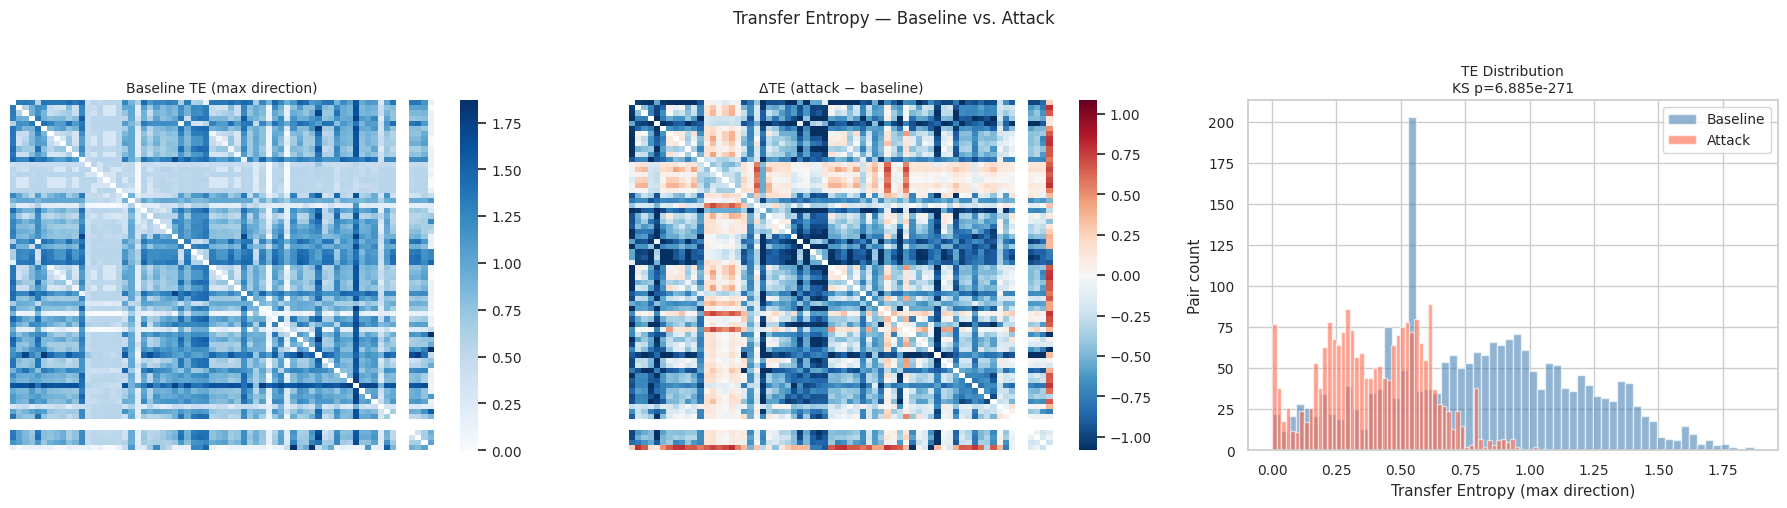

In [18]:
# ── TE visualizations ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Heatmap: baseline TE (max across directions)
sensors_sorted = sorted(sensor_cols)
n_s = len(sensors_sorted)
sensor_idx = {s: i for i, s in enumerate(sensors_sorted)}

te_base_mat = np.full((n_s, n_s), np.nan)
for row in te_combined.iter_rows(named=True):
    i, j = sensor_idx.get(row["sensor_a"]), sensor_idx.get(row["sensor_b"])
    if i is not None and j is not None:
        te_base_mat[i, j] = row["te_max_baseline"]
        te_base_mat[j, i] = row["te_max_baseline"]

te_delta_mat = np.full((n_s, n_s), np.nan)
for row in te_combined.iter_rows(named=True):
    i, j = sensor_idx.get(row["sensor_a"]), sensor_idx.get(row["sensor_b"])
    if i is not None and j is not None:
        te_delta_mat[i, j] = row["te_delta"]
        te_delta_mat[j, i] = row["te_delta"]

# Heatmap 1: baseline TE
sns.heatmap(te_base_mat, ax=axes[0], cmap="Blues", cbar=True,
            xticklabels=False, yticklabels=False)
axes[0].set_title("Baseline TE (max direction)", fontsize=10)

# Heatmap 2: Δ TE (attack − baseline)
vmax = np.nanpercentile(np.abs(te_delta_mat), 95)
sns.heatmap(te_delta_mat, ax=axes[1], cmap="RdBu_r", center=0,
            vmin=-vmax, vmax=vmax, cbar=True,
            xticklabels=False, yticklabels=False)
axes[1].set_title("ΔTE (attack − baseline)", fontsize=10)

# Distribution: baseline vs. attack TE across all pairs
axes[2].hist(te_baseline_vals[~np.isnan(te_baseline_vals)], bins=60,
             alpha=0.6, label="Baseline", color="steelblue")
axes[2].hist(te_attack_vals[~np.isnan(te_attack_vals)], bins=60,
             alpha=0.6, label="Attack", color="tomato")
axes[2].set_xlabel("Transfer Entropy (max direction)")
axes[2].set_ylabel("Pair count")
axes[2].set_title(f"TE Distribution\nKS p={ks_pval:.3e}", fontsize=10)
axes[2].legend()

plt.suptitle("Transfer Entropy — Baseline vs. Attack", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
## Section 4 — Mutual Information

Continuous KNN estimator from npeet (no discretization).
MI is symmetric — MI(X,Y) = MI(Y,X) — so only one value per pair.
Same baseline-vs-attack methodology as TE.


In [19]:
from sklearn.feature_selection import mutual_info_regression


def compute_mi_pair(sa, sb, norm_dict):
    """Compute continuous MI using sklearn's KNN MI estimator (KSG, same k as TE)."""
    x = _sample(norm_dict.get(sa, np.array([])), MI_SUBSAMPLE_N)
    y = _sample(norm_dict.get(sb, np.array([])), MI_SUBSAMPLE_N)
    n = min(len(x), len(y))
    if n < 50:
        return np.nan
    x, y = x[:n], y[:n]
    if x.std() < 1e-9 or y.std() < 1e-9:
        return np.nan
    try:
        val = float(mutual_info_regression(
            x.reshape(-1, 1), y, n_neighbors=TE_KNN_K, random_state=0
        )[0])
        return max(0.0, val)   # KSG bias can push near-zero MI slightly negative
    except Exception:
        return np.nan


In [20]:
# ── Baseline MI ───────────────────────────────────────────────────────────────
print(f"Computing baseline MI on {len(all_pairs):,} pairs (subsample={MI_SUBSAMPLE_N}) …")

def _mi_row(sa, sb):
    mi_base = compute_mi_pair(sa, sb, normalized_normal)
    mi_atk  = compute_mi_pair(sa, sb, normalized_attack)
    return {"sensor_a": sa, "sensor_b": sb,
            "mi_baseline": mi_base, "mi_attack": mi_atk}

mi_rows = Parallel(n_jobs=-1, prefer="threads")(
    delayed(_mi_row)(sa, sb) for sa, sb in tqdm(all_pairs)
)

mi_combined = (
    pl.DataFrame(mi_rows)
    .with_columns(
        pl.col("mi_baseline").fill_nan(None),
        pl.col("mi_attack").fill_nan(None),
    )
    .with_columns(
        (pl.col("mi_attack") - pl.col("mi_baseline")).alias("mi_delta"),
        (
            (pl.col("mi_attack") - pl.col("mi_baseline")).abs()
            / (pl.col("mi_baseline").abs() + 1e-9)
        ).alias("mi_rel_deviation"),
    )
    .drop_nulls(["mi_baseline", "mi_attack"])
)

print(f"MI comparison: {mi_combined.height:,} valid pairs")
print(mi_combined.describe())


Computing baseline MI on 2,278 pairs (subsample=8000) …


100%|██████████| 2278/2278 [00:41<00:00, 55.13it/s]


MI comparison: 2,145 valid pairs
shape: (9, 7)
┌────────────┬───────────────┬───────────────┬─────────────┬───────────┬───────────┬───────────────┐
│ statistic  ┆ sensor_a      ┆ sensor_b      ┆ mi_baseline ┆ mi_attack ┆ mi_delta  ┆ mi_rel_deviat │
│ ---        ┆ ---           ┆ ---           ┆ ---         ┆ ---       ┆ ---       ┆ ion           │
│ str        ┆ str           ┆ str           ┆ f64         ┆ f64       ┆ f64       ┆ ---           │
│            ┆               ┆               ┆             ┆           ┆           ┆ f64           │
╞════════════╪═══════════════╪═══════════════╪═════════════╪═══════════╪═══════════╪═══════════════╡
│ count      ┆ 2145          ┆ 2145          ┆ 2145.0      ┆ 2145.0    ┆ 2145.0    ┆ 2145.0        │
│ null_count ┆ 0             ┆ 0             ┆ 0.0         ┆ 0.0       ┆ 0.0       ┆ 0.0           │
│ mean       ┆ null          ┆ null          ┆ 2.721549    ┆ 2.233156  ┆ -0.488393 ┆ 1.0776e7      │
│ std        ┆ null          ┆ null         

In [21]:
# ── MI significance assessment ────────────────────────────────────────────────
mi_baseline_vals = mi_combined["mi_baseline"].to_numpy()
mi_attack_vals   = mi_combined["mi_attack"].to_numpy()

ks_stat_mi, ks_pval_mi = ks_2samp(mi_baseline_vals, mi_attack_vals)
print(f"Population KS test — statistic: {ks_stat_mi:.4f}  p-value: {ks_pval_mi:.4e}")
print(f"  Interpretation: {'significant shift' if ks_pval_mi < SIGNIFICANCE_ALPHA else 'no significant shift'} "
      f"in MI distribution during attacks")

delta_mi_z = zscore(mi_combined["mi_delta"].to_numpy(), nan_policy="omit")
mi_combined = mi_combined.with_columns(
    pl.Series("mi_delta_zscore", delta_mi_z)
).with_columns(
    (pl.col("mi_delta_zscore").abs() > DEVIATION_ZSCORE_THRESH).alias("mi_significant")
)

n_mi_sig = mi_combined["mi_significant"].sum()
print(f"\nPer-pair MI significance (|z| > {DEVIATION_ZSCORE_THRESH}):")
print(f"  {n_mi_sig:,} / {mi_combined.height:,} pairs flagged  "
      f"({100*n_mi_sig/mi_combined.height:.1f}%)")

print("\nTop 15 pairs by |Δ_MI|:")
print(
    mi_combined
    .sort("mi_rel_deviation", descending=True)
    .head(15)
    .select(["sensor_a", "sensor_b", "mi_baseline", "mi_attack",
             "mi_delta", "mi_delta_zscore", "mi_significant"])
)


Population KS test — statistic: 0.2872  p-value: 2.5086e-78
  Interpretation: significant shift in MI distribution during attacks

Per-pair MI significance (|z| > 2.0):
  75 / 2,145 pairs flagged  (3.5%)

Top 15 pairs by |Δ_MI|:
shape: (15, 7)
┌───────────────┬───────────────┬─────────────┬───────────┬──────────┬──────────────┬──────────────┐
│ sensor_a      ┆ sensor_b      ┆ mi_baseline ┆ mi_attack ┆ mi_delta ┆ mi_delta_zsc ┆ mi_significa │
│ ---           ┆ ---           ┆ ---         ┆ ---       ┆ ---      ┆ ore          ┆ nt           │
│ str           ┆ str           ┆ f64         ┆ f64       ┆ f64      ┆ ---          ┆ ---          │
│               ┆               ┆             ┆           ┆          ┆ f64          ┆ bool         │
╞═══════════════╪═══════════════╪═════════════╪═══════════╪══════════╪══════════════╪══════════════╡
│ consumer_flow ┆ elevated_flow ┆ 0.0         ┆ 1.686732  ┆ 1.686732 ┆ 1.761803     ┆ false        │
│ _ctrl_setpoin ┆ _sensor_3     ┆             ┆  

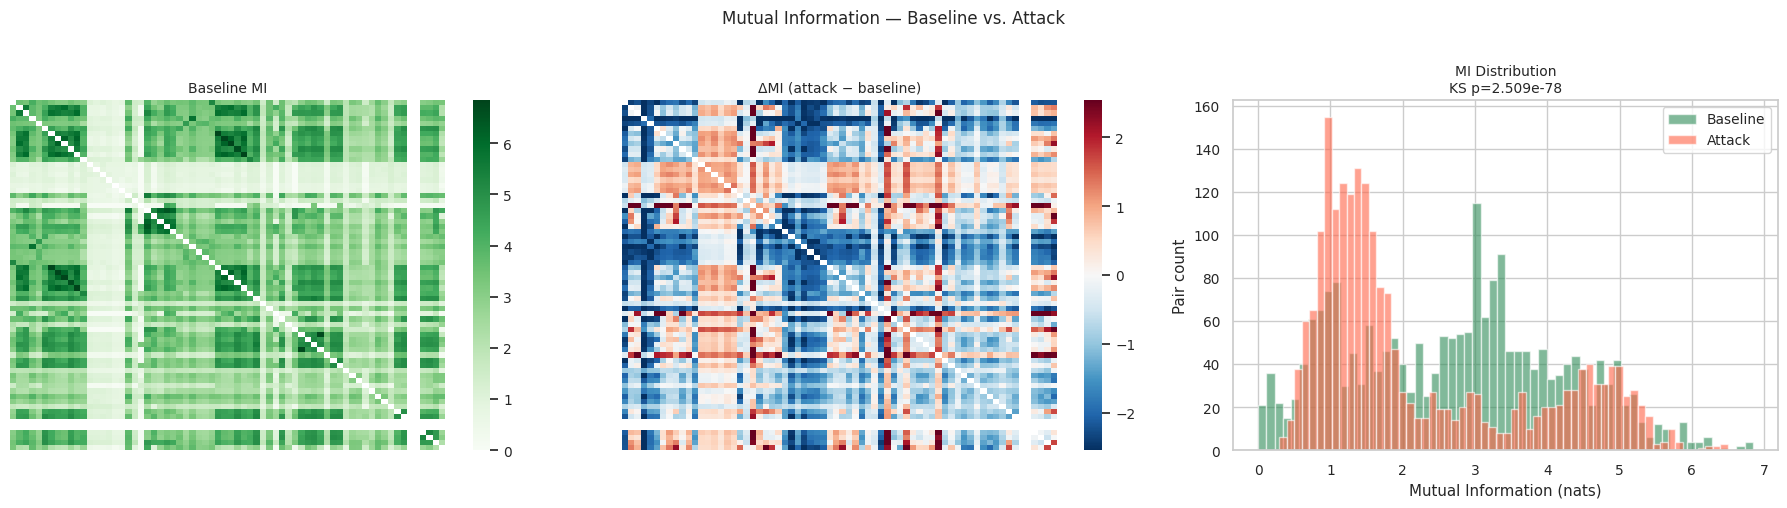

In [22]:
# ── MI visualizations ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mi_base_mat  = np.full((n_s, n_s), np.nan)
mi_delta_mat = np.full((n_s, n_s), np.nan)
for row in mi_combined.iter_rows(named=True):
    i, j = sensor_idx.get(row["sensor_a"]), sensor_idx.get(row["sensor_b"])
    if i is not None and j is not None:
        mi_base_mat[i, j] = mi_base_mat[j, i] = row["mi_baseline"]
        mi_delta_mat[i, j] = mi_delta_mat[j, i] = row["mi_delta"]

sns.heatmap(mi_base_mat, ax=axes[0], cmap="Greens", cbar=True,
            xticklabels=False, yticklabels=False)
axes[0].set_title("Baseline MI", fontsize=10)

vmax_mi = np.nanpercentile(np.abs(mi_delta_mat), 95)
sns.heatmap(mi_delta_mat, ax=axes[1], cmap="RdBu_r", center=0,
            vmin=-vmax_mi, vmax=vmax_mi, cbar=True,
            xticklabels=False, yticklabels=False)
axes[1].set_title("ΔMI (attack − baseline)", fontsize=10)

axes[2].hist(mi_baseline_vals[~np.isnan(mi_baseline_vals)], bins=60,
             alpha=0.6, label="Baseline", color="seagreen")
axes[2].hist(mi_attack_vals[~np.isnan(mi_attack_vals)], bins=60,
             alpha=0.6, label="Attack", color="tomato")
axes[2].set_xlabel("Mutual Information (nats)")
axes[2].set_ylabel("Pair count")
axes[2].set_title(f"MI Distribution\nKS p={ks_pval_mi:.3e}", fontsize=10)
axes[2].legend()

plt.suptitle("Mutual Information — Baseline vs. Attack", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
## Section 6 — Cross-Metric Comparison

Build a unified summary across four metrics: CCF, Granger, TE, and MI.
If `wadi_edges.csv` from the CCF/Granger notebook is not present, that notebook must be run first.


In [1]:
# ── Load CCF/Granger results ─────────────────────────────────────────────────
if EDGES_CSV.exists():
    edges_df = pl.read_csv(EDGES_CSV)
    print(f"Loaded wadi_edges.csv: {edges_df.height} pairs")
    print(f"Columns: {edges_df.columns}")
else:
    print(f"WARNING: {EDGES_CSV} not found — run the CCF/Granger notebook first.")
    print("Creating placeholder with CCF/Granger columns set to None.")
    edges_df = pl.DataFrame({
        "sensor_a": [r[0] for r in all_pairs[:100]],
        "sensor_b": [r[1] for r in all_pairs[:100]],
        "ccf_significant":     [None] * 100,
        "granger_significant": [None] * 100,
    })


NameError: name 'EDGES_CSV' is not defined

In [ ]:
# ── Normalise CCF/Granger edge frame to pair-level boolean flags ─────────────
# wadi_edges.csv contains only Granger-significant pairs annotated with CCF.
# Reconstruct full pair set with False for missing entries.

all_pairs_df = pl.DataFrame({
    "sensor_a": [p[0] for p in all_pairs],
    "sensor_b": [p[1] for p in all_pairs],
})

# CCF flag
ccf_flags = (
    edges_df.select(["sensor_a", "sensor_b", "ccf_category"])
    .with_columns(
        (pl.col("ccf_category") == "clearly_significant").alias("ccf_significant")
    )
    .select(["sensor_a", "sensor_b", "ccf_significant"])
) if "ccf_category" in edges_df.columns else (
    edges_df.select(["sensor_a", "sensor_b"])
    .with_columns(pl.lit(None).cast(pl.Boolean).alias("ccf_significant"))
)

# Granger flag
granger_flags = (
    edges_df.select(["sensor_a", "sensor_b"])
    .with_columns(pl.lit(True).alias("granger_significant"))
) if edges_df.height > 0 else (
    pl.DataFrame({"sensor_a": [], "sensor_b": [],
                  "granger_significant": []}).cast({"granger_significant": pl.Boolean})
)

# TE flag
te_flags = te_combined.select(["sensor_a", "sensor_b", "te_significant"])

# MI flag
mi_flags = mi_combined.select(["sensor_a", "sensor_b", "mi_significant"])

# Join all four
summary_df = (
    all_pairs_df
    .join(ccf_flags,     on=["sensor_a", "sensor_b"], how="left")
    .join(granger_flags, on=["sensor_a", "sensor_b"], how="left")
    .join(te_flags,      on=["sensor_a", "sensor_b"], how="left")
    .join(mi_flags,      on=["sensor_a", "sensor_b"], how="left")
    .with_columns(
        pl.col("ccf_significant").fill_null(False),
        pl.col("granger_significant").fill_null(False),
        pl.col("te_significant").fill_null(False),
        pl.col("mi_significant").fill_null(False),
    )
)

print(f"Summary dataframe: {summary_df.height:,} rows × {summary_df.width} columns")
print(summary_df.head(5))


In [ ]:
# ── Percentage of sensor pairs flagged by each metric ────────────────────────
metric_cols = ["ccf_significant", "granger_significant", "te_significant", "mi_significant"]

n_total = summary_df.height
print(f"Pairs flagged as significant (out of {n_total:,} total):  [α={SIGNIFICANCE_ALPHA}]")
print("-" * 55)
for col in metric_cols:
    n_sig = summary_df[col].sum()
    print(f"  {col:<28}: {n_sig:>5,}  ({100*n_sig/n_total:5.1f}%)")

# ── Number of metrics that agree per pair ─────────────────────────────────────
summary_df = summary_df.with_columns(
    (
        pl.col("ccf_significant").cast(pl.Int32) +
        pl.col("granger_significant").cast(pl.Int32) +
        pl.col("te_significant").cast(pl.Int32) +
        pl.col("mi_significant").cast(pl.Int32)
    ).alias("n_metrics_agree")
)

agree_counts = (
    summary_df.group_by("n_metrics_agree")
    .agg(pl.len().alias("pair_count"))
    .sort("n_metrics_agree")
)
print("\nPairs by number of metrics in agreement:")
print(agree_counts)


In [ ]:
# ── Correlation matrix across metric flags ───────────────────────────────────
metric_pd = summary_df.select(metric_cols).to_pandas().astype(int)
metric_corr = metric_pd.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(metric_corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=axes[0],
            xticklabels=[c.replace("_significant","") for c in metric_cols],
            yticklabels=[c.replace("_significant","") for c in metric_cols])
axes[0].set_title("Metric Flag Correlation Matrix\n"
                  "(1 = metrics flag same pairs, 0 = independent)", fontsize=10)

# Bar chart: pairs flagged per metric
n_sig_per_metric = [summary_df[c].sum() for c in metric_cols]
colors = ["#4472C4", "#ED7D31", "#A9D18E", "#FF99CC"]
axes[1].bar([c.replace("_significant","") for c in metric_cols],
            n_sig_per_metric, color=colors, edgecolor="white")
axes[1].set_ylabel("Number of flagged pairs")
axes[1].set_title("Pairs Flagged Significant per Metric", fontsize=10)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [ ]:
# ── Upset plot — which pairs are flagged by which combination of metrics ─────
try:
    from upsetplot import from_indicators, UpSet

    upset_df = summary_df.select(metric_cols).to_pandas().astype(bool)
    upset_df.columns = [c.replace("_significant", "") for c in metric_cols]

    upset_data = from_indicators(upset_df.columns.tolist(), data=upset_df)
    fig = plt.figure(figsize=(14, 6))
    UpSet(upset_data, subset_size="count", show_counts=True).plot(fig)
    plt.suptitle("UpSet Plot — Overlap of Metric Flags Across Sensor Pairs", fontsize=11)
    plt.show()

except ImportError:
    print("upsetplot not available — using bar chart of combination counts instead.")
    # Manual combination counts
    from collections import Counter
    combo_counts = Counter()
    for row in summary_df.select(metric_cols).iter_rows(named=True):
        key = tuple(sorted(c.replace("_significant","")
                           for c, v in row.items() if v))
        combo_counts[key] += 1
    top_combos = combo_counts.most_common(15)
    labels = ["+".join(k) if k else "none" for k, _ in top_combos]
    values = [v for _, v in top_combos]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(labels)), values, color="steelblue", edgecolor="white")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Pair count")
    ax.set_title("Top 15 Metric Flag Combinations", fontsize=10)
    plt.tight_layout()
    plt.show()


In [ ]:
# ── Agreement vs. disagreement pairs ─────────────────────────────────────────
all_agree = summary_df.filter(pl.col("n_metrics_agree") == 4)
all_disagree_partial = summary_df.filter(
    (pl.col("n_metrics_agree") >= 2) & (pl.col("n_metrics_agree") <= 3)
)
none_agree = summary_df.filter(pl.col("n_metrics_agree") == 0)

print(f"All 4 metrics agree (flagged)       : {all_agree.height:,} pairs")
print(f"Partial agreement (2–3 of 4 metrics): {all_disagree_partial.height:,} pairs  ← interesting edge cases")
print(f"No metric flags                     : {none_agree.height:,} pairs")

print("\nTop pairs where ALL metrics agree:")
print(all_agree.head(20).select(["sensor_a", "sensor_b", "n_metrics_agree"]))

print("\nTop partial-agreement pairs (disagreement is analytically interesting):")
print(
    all_disagree_partial
    .head(20)
    .select(["sensor_a", "sensor_b", "n_metrics_agree"] + metric_cols)
    .rename({c: c.replace("_significant","") for c in metric_cols})
)


---
## Section 7 — Build and Serialize NetworkX Graphs

Builds four NetworkX graph objects from the CCF/Granger, TE, and MI analysis results and
serializes them to `../../data/graphs/` for use by the `graph_viz/` visualization module.


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pickle
import networkx as nx
from pathlib import Path

GRAPHS_DIR = Path("../../data/graphs")
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

# ── Persist DataFrames so encoding_experiments.ipynb can reload them ──────────
te_combined.write_parquet(GRAPHS_DIR / "te_combined.parquet")
mi_combined.write_parquet(GRAPHS_DIR / "mi_combined.parquet")
stationarity_df.write_parquet(GRAPHS_DIR / "stationarity_df.parquet")
print("Saved DataFrames to", GRAPHS_DIR)

# ── Node attribute lookup tables ──────────────────────────────────────────────
STAGE_TO_ID      = {"P1": 0, "P2A": 1, "P2B": 2, "P3": 3, "system": 4}
# cluster: P1+P2A=primary treatment(0), P2B=consumer distribution(1), P3=return(2), system(3)
STAGE_TO_CLUSTER = {"P1": 0, "P2A": 0, "P2B": 1, "P3": 2, "system": 3}
# physical pipeline order for hop distance
PIPELINE_IDX     = {"system": 0, "P1": 1, "P2A": 2, "P2B": 3, "P3": 4}
STAT_GROUP_MAP   = {1: "difference", 2: "stationary", 3: "detrend"}

sensor_to_stage: dict[str, str] = {}
sensor_to_type:  dict[str, str] = {}
for row in data_dict.filter(pl.col("kind") == "continuous").iter_rows(named=True):
    name  = (row.get("short_name") or "").strip()
    stage = (row.get("stage") or "").strip() or "system"
    role  = (row.get("role") or "Unknown").strip()
    if name:
        sensor_to_stage[name] = stage
        sensor_to_type[name]  = "actuator" if role == "Actuator" else "sensor"

sensor_to_stat: dict[str, str] = {
    row["sensor"]: STAT_GROUP_MAP.get(row["stationarity_group"], "stationary")
    for row in stationarity_df.iter_rows(named=True)
}

def _node_attrs(n: str) -> dict:
    stage = sensor_to_stage.get(n, "system")
    return {
        "subsystem_id":       STAGE_TO_ID.get(stage, 4),
        "cluster_id":         STAGE_TO_CLUSTER.get(stage, 3),
        "node_type":          sensor_to_type.get(n, "sensor"),
        "stationarity_class": sensor_to_stat.get(n, "stationary"),
    }

def _phop(na: str, nb: str) -> int:
    ia = PIPELINE_IDX.get(sensor_to_stage.get(na, "system"), 0)
    ib = PIPELINE_IDX.get(sensor_to_stage.get(nb, "system"), 0)
    return abs(ia - ib) + 1

# ── Load CCF / Granger edges ───────────────────────────────────────────────────
_edges = pl.read_csv(Path("wadi_edges.csv"))

# frozenset key → row dict for undirected CCF lookup
_ccf_by_fset: dict = {}
for _row in _edges.iter_rows(named=True):
    _ccf_by_fset[frozenset([_row["sensor_a"], _row["sensor_b"]])] = _row

# CCF-significant frozenset keys
_ccf_sig: set = frozenset(
    frozenset([r["sensor_a"], r["sensor_b"]])
    for r in _edges.filter(pl.col("ccf_category") == "clearly_significant").iter_rows(named=True)
)

# ordered pair → row dict for Granger direction lookup
_granger_ordered: dict = {
    (r["sensor_a"], r["sensor_b"]): r
    for r in _edges.iter_rows(named=True)
}

# ── MI lookups ─────────────────────────────────────────────────────────────────
_mi_by_fset: dict = {}
for _row in mi_combined.iter_rows(named=True):
    _mi_by_fset[frozenset([_row["sensor_a"], _row["sensor_b"]])] = _row

_mi_sig: set = frozenset(
    frozenset([r["sensor_a"], r["sensor_b"]])
    for r in mi_combined.filter(pl.col("mi_significant")).iter_rows(named=True)
)

# ── TE lookups ─────────────────────────────────────────────────────────────────
_te_by_pair: dict = {
    (r["sensor_a"], r["sensor_b"]): r
    for r in te_combined.iter_rows(named=True)
}

_te_sig: set = frozenset(
    frozenset([r["sensor_a"], r["sensor_b"]])
    for r in te_combined.filter(pl.col("te_significant")).iter_rows(named=True)
)

# ── Build undirected graph (CCF + MI) ─────────────────────────────────────────
def _build_undir(use_attack: bool) -> nx.Graph:
    G = nx.Graph()
    for s in sensor_cols:
        G.add_node(s, **_node_attrs(s))

    for fkey in (_ccf_sig | _mi_sig):
        pair   = sorted(fkey)
        sa, sb = pair[0], pair[1]
        in_ccf = fkey in _ccf_sig
        in_mi  = fkey in _mi_sig
        etype  = "both" if (in_ccf and in_mi) else ("ccf_only" if in_ccf else "mi_only")

        ccf_row  = _ccf_by_fset.get(fkey)
        raw_peak = ccf_row.get("peak_ccf") if ccf_row else None
        ccf_val  = abs(float(raw_peak)) if raw_peak is not None else 0.0

        mi_row = _mi_by_fset.get(fkey)
        if mi_row:
            raw_mi = mi_row["mi_attack"] if use_attack else mi_row["mi_baseline"]
            mi_val = float(raw_mi) if raw_mi is not None else 0.0
        else:
            mi_val = 0.0

        G.add_edge(sa, sb,
            ccf_delta    = ccf_val,
            mi_value     = mi_val,
            physical_hop = _phop(sa, sb),
            edge_type    = etype,
            is_intra     = (sensor_to_stage.get(sa, "system") == sensor_to_stage.get(sb, "system")),
        )
    return G

# ── Build directed graph (Granger + TE) ───────────────────────────────────────
def _build_dir(use_attack: bool) -> nx.DiGraph:
    G = nx.DiGraph()
    for s in sensor_cols:
        G.add_node(s, **_node_attrs(s))

    # candidate (src, tgt) → edge_type
    candidates: dict[tuple, str] = {}

    # All Granger pairs — orient by direction column
    for (sa, sb), row in _granger_ordered.items():
        direction = row.get("direction") or ""
        if "→" in direction:
            parts = direction.split("→")
            src, tgt = parts[0].strip(), parts[1].strip()
        else:
            src, tgt = sa, sb
        if src in G and tgt in G:
            fkey   = frozenset([src, tgt])
            in_te  = fkey in _te_sig
            candidates[(src, tgt)] = "both" if in_te else "granger_only"

    # TE-significant pairs not yet covered
    for _row in te_combined.filter(pl.col("te_significant")).iter_rows(named=True):
        sa, sb = _row["sensor_a"], _row["sensor_b"]
        te_xy  = _row.get("te_xy_baseline") or 0.0
        te_yx  = _row.get("te_yx_baseline") or 0.0
        src, tgt = (sa, sb) if (te_xy or 0) >= (te_yx or 0) else (sb, sa)
        if (src, tgt) not in candidates and src in G and tgt in G:
            candidates[(src, tgt)] = "te_only"

    for (src, tgt), etype in candidates.items():
        # TE value
        te_row = _te_by_pair.get((src, tgt)) or _te_by_pair.get((tgt, src))
        if te_row:
            sa_key = te_row["sensor_a"]
            if src == sa_key:
                raw_te = te_row.get("te_xy_attack" if use_attack else "te_xy_baseline")
            else:
                raw_te = te_row.get("te_yx_attack" if use_attack else "te_yx_baseline")
            te_val = float(raw_te) if raw_te is not None else 0.0
        else:
            te_val = 0.0

        # Granger lag
        g_row = _granger_ordered.get((src, tgt)) or _granger_ordered.get((tgt, src))
        g_lag = int(g_row["optimal_lag"]) if g_row and g_row.get("optimal_lag") is not None else 1

        # CCF lag direction
        if g_row:
            direction = g_row.get("direction") or ""
            if "→" in direction:
                d_src = direction.split("→")[0].strip()
                ccf_lag_dir = "A_leads_B" if d_src == src else "B_leads_A"
            else:
                ccf_lag_dir = "A_leads_B"
        else:
            ccf_lag_dir = "A_leads_B"

        G.add_edge(src, tgt,
            te_value         = te_val,
            granger_lag      = g_lag,
            ccf_lag_direction= ccf_lag_dir,
            edge_type        = etype,
            is_intra         = (sensor_to_stage.get(src, "system") == sensor_to_stage.get(tgt, "system")),
        )
    return G

# ── Construct all four graphs ─────────────────────────────────────────────────
G_undir_normal = _build_undir(False)
G_undir_attack = _build_undir(True)
G_dir_normal   = _build_dir(False)
G_dir_attack   = _build_dir(True)

print(f"G_undir_normal : {G_undir_normal.number_of_nodes()} nodes, {G_undir_normal.number_of_edges()} edges")
print(f"G_undir_attack : {G_undir_attack.number_of_nodes()} nodes, {G_undir_attack.number_of_edges()} edges")
print(f"G_dir_normal   : {G_dir_normal.number_of_nodes()} nodes, {G_dir_normal.number_of_edges()} edges")
print(f"G_dir_attack   : {G_dir_attack.number_of_nodes()} nodes, {G_dir_attack.number_of_edges()} edges")

# Edge type distributions
for label, G in [("undir_normal", G_undir_normal), ("dir_normal", G_dir_normal)]:
    from collections import Counter
    etype_counts = Counter(d.get("edge_type") for _, _, d in G.edges(data=True))
    print(f"  {label} edge_type distribution: {dict(etype_counts)}")

# ── Serialize ─────────────────────────────────────────────────────────────────
for name, G in [("G_undir_normal", G_undir_normal), ("G_undir_attack", G_undir_attack),
                ("G_dir_normal",   G_dir_normal),   ("G_dir_attack",   G_dir_attack)]:
    with open(GRAPHS_DIR / f"{name}.pkl", "wb") as fh:
        pickle.dump(G, fh)

print(f"\nAll graphs serialized to {GRAPHS_DIR.resolve()}/")
